In [ ]:
import pandas as pd
import datetime
import requests
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# - CoinGecko — 무료로 비트코인 과거 가격 데이터를 CSV 또는 API로 제공.
# - CryptoDataDownload.com — 암호화폐 과거 시세(일봉, 시간봉 등) CSV를 무료로 제공.
# - CoinMarketCap 의 Historical Data 페이지 — BTC의 과거 종가/시가/거래량 등을 확인하고 CSV로 다운로드 가능.
# → 위 출처 중 하나에서 CSV로 다운로드하거나, API를 통해 자동으로 데이터를 받아올 수 있음.

In [ ]:
# 유의사항 / 한계

# 암호화폐 시장은 24시간, 7일 연속 운영되므로, 시계열 분석 시 타임존 / 시간 정확도에 주의해야 함
# 일부 API/사이트는 분봉 데이터 제공하지만, 무료 버전은 기간/횟수 제한이 있을 수 있음
# 과거 데이터의 공백(거래량 0, 일부 결측치 등)이 있을 수 있으므로 결측치 처리 필요
# 단순 과거 값만으로 미래 예측은 불확실성이 크므로, 분석 목적과 가정을 명확히 할 것

In [ ]:
# 1) CoinGecko API를 사용해 최근 5년치 일봉 가격 가져오기
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
params = {
    "vs_currency": "usd",
    "days": 365,  # 약 1년치 데이터
    "interval": "daily"
}

In [ ]:
resp = requests.get(url, params=params)
data = resp.json()

In [ ]:
type(data)

dict

In [ ]:
data.keys()

dict_keys(['prices', 'market_caps', 'total_volumes'])

In [ ]:
# 'prices' 항목이 [timestamp, price] 리스트로 반환
df = pd.DataFrame(data["prices"], columns=["timestamp", "price_usd"])
df["date"] = pd.to_datetime(df["timestamp"], unit="ms")
df.set_index("date", inplace=True)
df = df.drop(columns="timestamp")

In [ ]:
print(df.head())
print(df.tail())
print("데이터 개수:", len(df))

               price_usd
date                    
2024-11-27  91931.830773
2024-11-28  95981.180572
2024-11-29  95661.595958
2024-11-30  97453.247345
2024-12-01  96513.142347
                        price_usd
date                             
2025-11-23 00:00:00  84682.624291
2025-11-24 00:00:00  86783.847668
2025-11-25 00:00:00  88229.357407
2025-11-26 00:00:00  87310.331600
2025-11-26 15:20:31  87109.117471
데이터 개수: 366


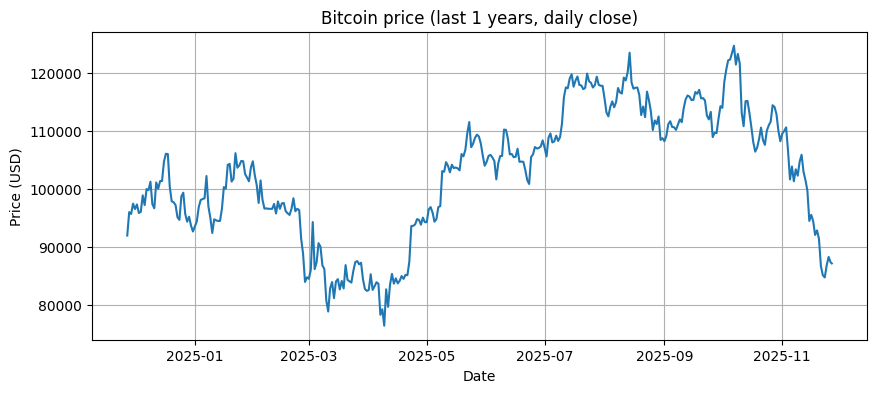

In [ ]:
# 2) 간단한 시계열 시각화
plt.figure(figsize=(10, 4))
plt.plot(df.index, df["price_usd"])
plt.title("Bitcoin price (last 1 years, daily close)")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.grid(True)
plt.show()

In [ ]:
btc = df.copy()

In [ ]:
# # 로그 가격
# btc["log_price"] = np.log(btc["price_usd"])

# # 일별 로그수익률 (r_t = log(P_t) - log(P_{t-1}))
# btc["log_return"] = btc["log_price"].diff()

# # 변동성: 30일 롤링 표준편차 (로그수익률 기준)
# window_vol = 30
# btc["vol_30d"] = btc["log_return"].rolling(window_vol).std() * np.sqrt(365)

In [ ]:
window_bb = 20
btc["ma20"] = btc["price_usd"].rolling(window_bb).mean()
btc["std20"] = btc["price_usd"].rolling(window_bb).std()
btc["bb_upper"] = btc["ma20"] + 2 * btc["std20"] #예측의 최대치 = 예상평균 + 분산*2
btc["bb_lower"] = btc["ma20"] - 2 * btc["std20"] #예측의 최소치 = 예상평균 - 분산*2

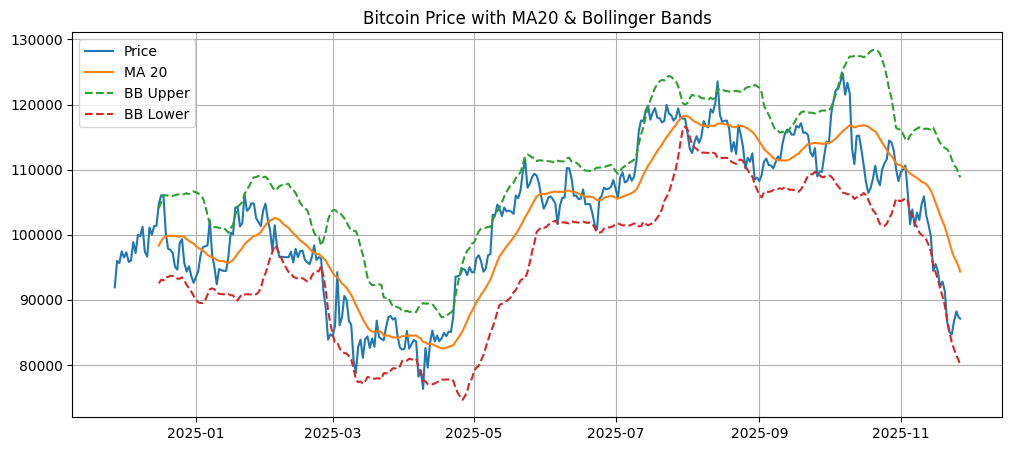

In [ ]:
# 이동평균 시각화 ==> 전체적으로 흐름을 한 표에 보자
# 이동평균(예측되는 평균), 변동성 지표(예상되는 최대치, 최소치가 어떻게 변할 것인가)
plt.figure(figsize=(12,5))
plt.plot(btc.index, btc["price_usd"], label="Price")
plt.plot(btc.index, btc["ma20"], label="MA 20")
plt.plot(btc.index, btc["bb_upper"], label="BB Upper", linestyle="--")
plt.plot(btc.index, btc["bb_lower"], label="BB Lower", linestyle="--")
plt.title("Bitcoin Price with MA20 & Bollinger Bands")
plt.legend()
plt.grid(True)
plt.show()

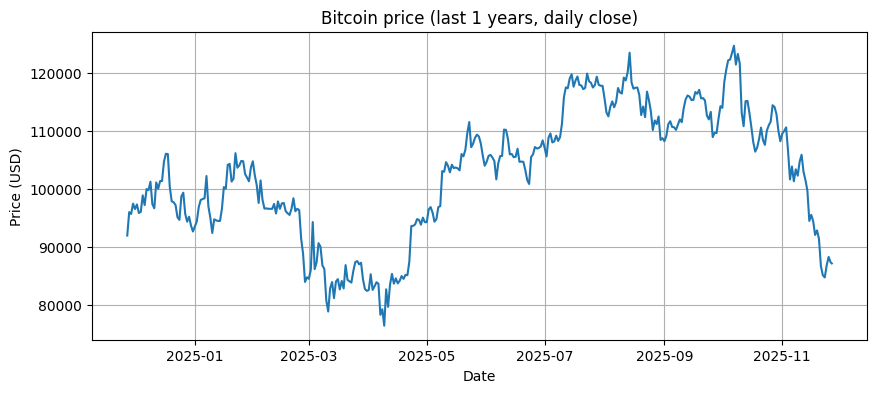

In [ ]:
# 2) 간단한 시계열 시각화
plt.figure(figsize=(10, 4))
plt.plot(df.index, df["price_usd"])
plt.title("Bitcoin price (last 1 years, daily close)")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.grid(True)
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# 결측 제거 (처음 diff 때문에 NaN 생김)
series = btc["price_usd"].dropna()

# ARIMA(p,d,q) = (2,1,2) 예시
model = ARIMA(series, order=(2,1,2))
result = model.fit()

print(result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              price_usd   No. Observations:                  366
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -3322.916
Date:                Wed, 26 Nov 2025   AIC                           6655.831
Time:                        15:20:39   BIC                           6675.331
Sample:                             0   HQIC                          6663.580
                                - 366                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2441      9.441     -0.026      0.979     -18.747      18.259
ar.L2          0.2547      5.599      0.045      0.964     -10.720      11.229
ma.L1          0.2774      9.444      0.029      0.9

In [ ]:
# 향후 30일 예측
forecast = result.get_forecast(steps=30)
pred_mean = forecast.predicted_mean
pred_ci = forecast.conf_int()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
print("예측평균 --------------\n", pred_mean) #상위 예측값 + 하위 예측값 평균
print("예측값 -------------\n", pred_ci) #상위 예측값 + 하위 예측값

예측평균 --------------
 366    87115.230349
367    87109.943594
368    87112.790910
369    87110.749382
370    87111.972888
371    87111.154273
372    87111.665708
373    87111.332375
374    87111.543997
375    87111.407444
376    87111.494675
377    87111.438603
378    87111.474507
379    87111.451462
380    87111.466231
381    87111.456757
382    87111.462831
383    87111.458935
384    87111.461433
385    87111.459832
386    87111.460859
387    87111.460200
388    87111.460622
389    87111.460352
390    87111.460525
391    87111.460414
392    87111.460485
393    87111.460440
394    87111.460469
395    87111.460450
Name: predicted_mean, dtype: float64
예측값 -------------
      lower price_usd  upper price_usd
366     82837.895679     91392.565020
367     80959.307042     93260.580146
368     79577.840755     94647.741065
369     78382.513064     95838.985700
370     77348.494874     96875.450901
371     76403.642655     97818.665891
372     75541.677472     98681.653944
373     74735.87282